In [1]:
# importing plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# importing pandas
import pandas as pd

# importing numpy
import numpy as np

# importing seaborn
import seaborn as sns

# importing matplotlib
import matplotlib.pyplot as plt

# creating a dictionary to store each companies color
company_colors = {
    "OpenAI": "#10A37F",
    "Google": "#4285F4",
    "Anthropic": "#E8643A",
    "xAI": "#8B5CF6",
    "ByteDance": "#325AB4",
    "Alibaba": "#FF6A00",
    "Kuaishou": "#EB3B5A",
    "Black Forest Labs": "#2D3436",
    "HiDream": "#0FB9B1",
    "Ideogram": "#E84393",
    "Recraft": "#FED330",
    "Midjourney": "#778CA3",
    "Runway": "#20BF6B",
    "Lightricks": "#2D98DA",
    "Pika": "#F7B731"
}

In [2]:
# loading and reading the text models dataset
url = "https://raw.githubusercontent.com/DagaVedant/AI-Productivity-Dataset-Creation/refs/heads/main/text_models_dataset.csv"
df = pd.read_csv(url)
df.head(7)

,Model Name,Company,Release Year,Estimated Training Cost (USD Millions),Input Token Cost (USD per 1M Tokens),Output Token Cost (USD per 1M Tokens),Coding Productivity Score,Data Analysis Productivity Score,Literature Research Productivity Score,AA Intelligence Index,Context Window (Tokens),Output Speed (Tokens per Sec),Knowledge Cutoff
0,GPT-5.5,OpenAI,2026,500,5.00,30.0,88.7,93.2,92.4,60,1000000,53.2,December 2025
1,Gemini 2.5 Pro,Google,2025,250,1.25,10.0,63.8,84.0,89.8,35,1000000,127.7,January 2025
2,Gemini 3.1 Pro,Google,2026,350,2.00,12.0,80.6,94.3,90.1,57,1000000,110.1,January 2025
3,Claude Sonnet 4.6,Anthropic,2026,200,3.00,15.0,79.6,74.1,91.8,52,1000000,44.5,August 2025
4,Claude Opus 4.8,Anthropic,2026,500,5.00,25.0,88.6,93.6,92.0,61,1000000,57.5,January 2026
5,Claude Fable 5,Anthropic,2026,750,10.00,50.0,95.0,95.0,91.5,65,1000000,60.3,January 2026
6,Grok 4.3,xAI,2026,500,1.25,2.5,70.8,90.1,91.0,53,1000000,143.5,December 2025


In [3]:
# sort models by their overall intelligence score
df_intel = df.sort_values("AA Intelligence Index", ascending=False)

# create a bar chart
fig = px.bar(
    df_intel,
    x="Model Name",
    y="AA Intelligence Index",
    color="Company",
    color_discrete_map=company_colors,
    title="Overall Intelligence by Model (Artificial Analysis Intelligence Index)",
    text="AA Intelligence Index"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Intelligence Index",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    yaxis_range=[0, 75],
    xaxis_tickangle=30
)

# show the chart
fig.show()

In [4]:
# sort models by their coding productivity score
df_coding = df.sort_values("Coding Productivity Score", ascending=True)

# create a horizontal bar chart
fig = px.bar(
    df_coding,
    x="Coding Productivity Score",
    y="Model Name",
    color="Company",
    color_discrete_map=company_colors,
    orientation="h",
    title="Coding Productivity Score by Model (SWE-bench Verified)",
    text="Coding Productivity Score"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Score (%)",
    yaxis_title="Model",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    xaxis_range=[0, 110]
)

# show the chart
fig.show()

In [5]:
# sort models by their data analysis score
df_data = df.sort_values("Data Analysis Productivity Score", ascending=False)

# create a bar chart
fig = px.bar(
    df_data,
    x="Model Name",
    y="Data Analysis Productivity Score",
    color="Company",
    color_discrete_map=company_colors,
    title="Data Analysis Productivity Score by Model (GPQA Diamond)",
    text="Data Analysis Productivity Score"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Score (%)",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    yaxis_range=[0, 105],
    xaxis_tickangle=30
)

# show the chart
fig.show()

In [6]:
# sort models by their literature research score
df_lit = df.sort_values("Literature Research Productivity Score", ascending=False)

# create a bar chart
fig = px.bar(
    df_lit,
    x="Model Name",
    y="Literature Research Productivity Score",
    color="Company",
    color_discrete_map=company_colors,
    title="Literature & Research Productivity Score by Model (MMLU)",
    text="Literature Research Productivity Score"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Score (%)",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    yaxis_range=[82, 97],
    xaxis_tickangle=30
)

# show the chart
fig.show()

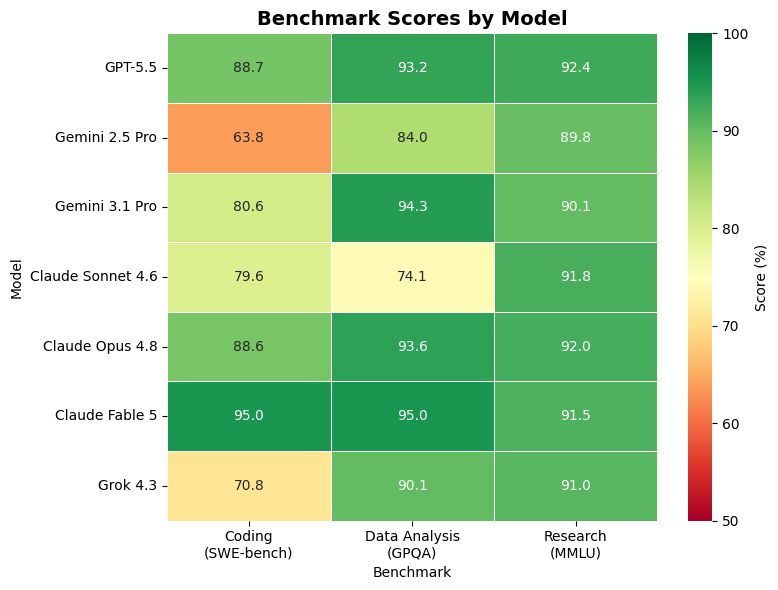

In [7]:
# pick the three benchmark scores and use the model names as the rows
benchmarks = [
    "Coding Productivity Score",
    "Data Analysis Productivity Score",
    "Literature Research Productivity Score"
]
heatmap_df = df.set_index("Model Name")[benchmarks]

# shorten the column names for the chart
heatmap_df.columns = ["Coding\n(SWE-bench)", "Data Analysis\n(GPQA)", "Research\n(MMLU)"]

# create the heatmap (red = low, green = high)
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=50,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Score (%)"}
)
plt.title("Benchmark Scores by Model", fontsize=14, fontweight="bold")
plt.xlabel("Benchmark")
plt.ylabel("Model")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

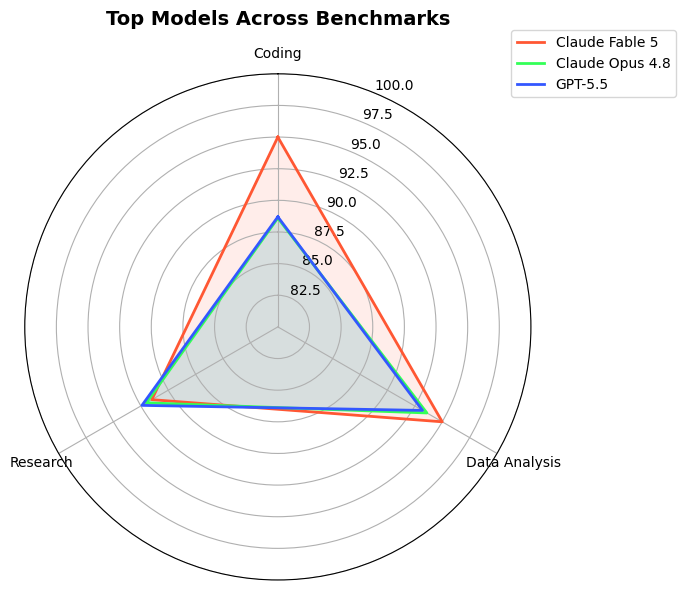

In [8]:
# define the benchmarks to compare and their short labels
benchmarks = [
    "Coding Productivity Score",
    "Data Analysis Productivity Score",
    "Literature Research Productivity Score"
]
labels = ["Coding", "Data Analysis", "Research"]

# pick the top 3 models by overall intelligence score
top_models = df.sort_values("AA Intelligence Index", ascending=False).head(3)

# set up one angle for each benchmark axis
angles = np.linspace(0, 2 * np.pi, len(benchmarks), endpoint=False).tolist()
angles += angles[:1]

# create the radar chart
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels)
ax.set_ylim(80, 100) # Adjusted y-axis limit for better visibility

# Define a list of distinct colors for the top models
distinct_colors = ["#FF5733", "#33FF57", "#3357FF"]

# draw one shape per model using distinct colors
for i, (_, row) in enumerate(top_models.iterrows()):
    values = row[benchmarks].tolist()
    values += values[:1]
    color = distinct_colors[i]
    ax.plot(angles, values, color=color, linewidth=2, label=row["Model Name"])
    ax.fill(angles, values, color=color, alpha=0.1)

# adding titles, legend, and made the graph look better
plt.title("Top Models Across Benchmarks", fontsize=14, fontweight="bold", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# show the chart
plt.show()

In [9]:
# sort each models by their release year
df_sorted = df.sort_values("Release Year")

# create an empty Plotly figure
fig = go.Figure()

# add a line connecting all models over time
fig.add_trace(go.Scatter(
    x=df_sorted["Model Name"],
    y=df_sorted["Estimated Training Cost (USD Millions)"],
    mode="lines",
    line=dict(color="#d0d0d0", width=2),
    showlegend=False
))

# add labeled data points for each company
for company in df_sorted["Company"].unique():
    comp_df = df_sorted[df_sorted["Company"] == company]
    fig.add_trace(go.Scatter(
        x=comp_df["Model Name"],
        y=comp_df["Estimated Training Cost (USD Millions)"],
        mode="markers+text",
        name=company,
        marker=dict(size=14, color=company_colors[company]),
        text=comp_df["Estimated Training Cost (USD Millions)"].apply(lambda x: f"${x}M"),
        textposition="top center"
    ))

# adding titles, axes, and styling
fig.update_layout(
    title="Estimated Training Costs of Frontier AI Models Over Time",
    xaxis_title="Model (ordered by release year)",
    yaxis_title="Estimated Training Cost (USD Millions)",
    yaxis_tickprefix="$",
    yaxis_ticksuffix="M",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# show the chart
fig.show()

In [10]:
# create two subplots for input and output token costs
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Input Cost (USD per 1M Tokens)", "Output Cost (USD per 1M Tokens)")
)

# add bar charts for each company
for company in df["Company"].unique():
    comp_df = df[df["Company"] == company]
    fig.add_trace(
        go.Bar(
            name=company,
            x=comp_df["Model Name"],
            y=comp_df["Input Token Cost (USD per 1M Tokens)"],
            marker_color=company_colors[company],
            legendgroup=company,
            showlegend=True
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(
            name=company,
            x=comp_df["Model Name"],
            y=comp_df["Output Token Cost (USD per 1M Tokens)"],
            marker_color=company_colors[company],
            legendgroup=company,
            showlegend=False
        ),
        row=1, col=2
    )

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    title="Input and Output Token Costs by Model",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# rotate x-axis labels for readability
fig.update_xaxes(tickangle=30)

# add dollar signs to both y-axes
fig.update_yaxes(tickprefix="$", row=1, col=1)
fig.update_yaxes(tickprefix="$", row=1, col=2)

# show the chart
fig.show()

In [11]:
# sort models by their output speed
df_speed = df.sort_values("Output Speed (Tokens per Sec)", ascending=False)

# create a bar chart
fig = px.bar(
    df_speed,
    x="Model Name",
    y="Output Speed (Tokens per Sec)",
    color="Company",
    color_discrete_map=company_colors,
    title="Output Speed by Model (Tokens per Second)",
    text="Output Speed (Tokens per Sec)"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Tokens per Second (higher = faster)",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    xaxis_tickangle=30
)

# show the chart
fig.show()

In [12]:
# create an empty figure
fig = go.Figure()

# add one set of points per company so the colors match the other charts
for company in df["Company"].unique():
    comp_df = df[df["Company"] == company]
    fig.add_trace(go.Scatter(
        x=comp_df["Output Token Cost (USD per 1M Tokens)"],
        y=comp_df["AA Intelligence Index"],
        mode="markers+text",
        name=company,
        marker=dict(size=16, color=company_colors[company]),
        text=comp_df["Model Name"],
        textposition="top center"
    ))

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    title="Intelligence vs Cost: Which Models Give the Most for the Money",
    xaxis_title="Output Token Cost (USD per 1M Tokens)",
    yaxis_title="Intelligence Index (higher = better)",
    xaxis_tickprefix="$",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# show the chart
fig.show()

In [13]:
# loading the image generation dataset (push the new csv to github first)
image_url = "https://raw.githubusercontent.com/DagaVedant/AI-Productivity-Dataset-Creation/refs/heads/main/image_models_dataset.csv"
image_df = pd.read_csv(image_url)
image_df.head(13)

,Model Name,Company,Arena Elo,Cost per Image (USD),Max Resolution,Weights
0,GPT Image 2,OpenAI,1338,0.02,4K,Proprietary
1,GPT Image 1.5,OpenAI,1266,0.05,4K,Proprietary
2,HiDream-O1-Image-1.5,HiDream,1264,0.03,2K,Open
3,Nano Banana 2 (Gemini 3.1 Flash Image),Google,1258,0.02,2K,Proprietary
4,Nano Banana Pro (Gemini 3 Pro Image),Google,1218,0.13,4K,Proprietary
5,Seedream 4.0,ByteDance,1202,0.03,4K,Proprietary
6,Flux 2 Pro,Black Forest Labs,1181,0.04,4K,Proprietary
7,Grok Imagine,xAI,1178,0.02,2K,Proprietary
8,Imagen 4 Ultra,Google,1173,0.06,2K,Proprietary
9,Ideogram 3.0,Ideogram,1132,0.03,2K,Proprietary


In [14]:
# sort image models by their arena elo score
image_sorted = image_df.sort_values("Arena Elo", ascending=True)

# create a horizontal bar chart (handles the long model names)
fig = px.bar(
    image_sorted,
    x="Arena Elo",
    y="Model Name",
    color="Company",
    color_discrete_map=company_colors,
    orientation="h",
    title="Image Generation Quality by Model (Arena Elo)",
    text="Arena Elo"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Arena Elo (higher = preferred by people)",
    yaxis_title="Model",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    xaxis_range=[1000, 1400]
)

# show the chart
fig.show()

In [15]:
# sort image models by their cost per image
image_cost = image_df.sort_values("Cost per Image (USD)", ascending=True)

# create a horizontal bar chart (handles the long model names)
fig = px.bar(
    image_cost,
    x="Cost per Image (USD)",
    y="Model Name",
    color="Company",
    color_discrete_map=company_colors,
    orientation="h",
    title="Cost per Image by Model (USD)",
    text="Cost per Image (USD)"
)

# add labels to each bar
fig.update_traces(texttemplate="$%{text:.2f}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Cost per Image (USD)",
    yaxis_title="Model",
    xaxis_tickprefix="$",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# show the chart
fig.show()

In [16]:
# create an empty figure
fig = go.Figure()

# add one set of points per company
for company in image_df["Company"].unique():
    comp_df = image_df[image_df["Company"] == company]
    fig.add_trace(go.Scatter(
        x=comp_df["Cost per Image (USD)"],
        y=comp_df["Arena Elo"],
        mode="markers+text",
        name=company,
        marker=dict(size=14, color=company_colors[company]),
        text=comp_df["Model Name"],
        textposition="top center"
    ))

# adding titles, axes, and styling
fig.update_layout(
    title="Image Models: Quality vs Cost per Image",
    xaxis_title="Cost per Image (USD)",
    yaxis_title="Arena Elo (higher = better)",
    xaxis_tickprefix="$",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# show the chart
fig.show()

In [17]:
# loading the video generation dataset (push the new csv to github first)
video_url = "https://raw.githubusercontent.com/DagaVedant/AI-Productivity-Dataset-Creation/refs/heads/main/video_models_dataset.csv"
video_df = pd.read_csv(video_url)
video_df.head(10)

,Model Name,Company,Arena Elo (No Audio),Cost per Second (USD),Max Clip Length (Sec),Max Resolution,Native Audio
0,Happy Horse 1.0,Alibaba,1293,0.22,10,1080p,Yes
1,Seedance 2.0,ByteDance,1274,0.15,20,1080p,Yes
2,Kling 3.0,Kuaishou,1250,0.34,15,4K,Yes
3,Runway Gen-4.5,Runway,1247,0.05,10,720p,No
4,Grok Imagine,xAI,1235,0.07,15,720p,Yes
5,Veo 3.1,Google,1245,0.40,60,4K,Yes
6,LTX-2 Pro,Lightricks,1135,0.06,20,4K,Yes
7,Pika 2.5,Pika,1195,0.03,5,1080p,Limited
8,Sora 2,OpenAI,1130,0.10,15,1080p,Yes
9,Sora 2 Pro,OpenAI,1150,0.50,25,1080p,Yes


In [18]:
# sort video models by their arena elo score
video_elo = video_df.sort_values("Arena Elo (No Audio)", ascending=False)

# create a bar chart
fig = px.bar(
    video_elo,
    x="Model Name",
    y="Arena Elo (No Audio)",
    color="Company",
    color_discrete_map=company_colors,
    title="Video Generation Quality by Model (Arena Elo, No Audio)",
    text="Arena Elo (No Audio)"
)

# add labels to each bar
fig.update_traces(texttemplate="%{text}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Arena Elo (higher = preferred by people)",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    yaxis_range=[1000, 1350],
    xaxis_tickangle=30
)

# show the chart
fig.show()

In [19]:
# sort video models by their cost per second
video_cost = video_df.sort_values("Cost per Second (USD)", ascending=False)

# create a bar chart
fig = px.bar(
    video_cost,
    x="Model Name",
    y="Cost per Second (USD)",
    color="Company",
    color_discrete_map=company_colors,
    title="Video Generation Cost by Model (USD per Second)",
    text="Cost per Second (USD)"
)

# add labels to each bar
fig.update_traces(texttemplate="$%{text:.2f}", textposition="outside")

# adding titles, x-axis, y-axis, and made the graph look better
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Cost per Second (USD)",
    yaxis_tickprefix="$",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company",
    xaxis_tickangle=30
)

# show the chart
fig.show()

In [20]:
# create an empty figure
fig = go.Figure()

# add one set of points per company
for company in video_df["Company"].unique():
    comp_df = video_df[video_df["Company"] == company]
    fig.add_trace(go.Scatter(
        x=comp_df["Cost per Second (USD)"],
        y=comp_df["Arena Elo (No Audio)"],
        mode="markers+text",
        name=company,
        marker=dict(size=14, color=company_colors[company]),
        text=comp_df["Model Name"],
        textposition="top center"
    ))

# adding titles, axes, and styling
fig.update_layout(
    title="Video Models: Quality vs Cost per Second",
    xaxis_title="Cost per Second (USD)",
    yaxis_title="Arena Elo (higher = better)",
    xaxis_tickprefix="$",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Company"
)

# show the chart
fig.show()